In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
import pickle
import json
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_PATH = Path('/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip')
print(f"Data path exists: {DATA_PATH.exists()}")

Using device: cuda
Data path exists: True


In [2]:
# Cell 2 (FIXED): Extract data first, then load .pkl

import zipfile
import pickle
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("STEP 1: Extract dataset (if not already extracted)")


INPUT_PATH = Path('/kaggle/input/competitions/data-science-bowl-2018')
WORK_DIR = Path('/kaggle/working/dsb2018')
WORK_DIR.mkdir(exist_ok=True)

# Extract training data if not already extracted
train_zip = INPUT_PATH / 'stage1_train.zip'
if train_zip.exists():
    print(f"Extracting {train_zip.name}...")
    with zipfile.ZipFile(train_zip, 'r') as zip_ref:
        zip_ref.extractall(WORK_DIR)
    print("Extraction complete!")
else:
    print(f"{train_zip.name} not found!")

# Set train path
train_path = WORK_DIR / 'stage1_train'
if not train_path.exists():
    train_path = WORK_DIR

print(f"Train path: {train_path}")
print(f"Exists: {train_path.exists()}")

# Verify by checking one folder
if train_path.exists():
    sample_folders = [d for d in train_path.iterdir() if d.is_dir()]
    print(f"Found {len(sample_folders)} image folders")
    
    # Check one sample
    if len(sample_folders) > 0:
        sample = sample_folders[0]
        images_folder = sample / 'images'
        if images_folder.exists():
            img_files = list(images_folder.glob('*.png'))
            print(f" Sample image exists: {len(img_files)} file(s)")

STEP 1: Extract dataset (if not already extracted)
Extracting stage1_train.zip...
Extraction complete!
Train path: /kaggle/working/dsb2018
Exists: True
Found 670 image folders
 Sample image exists: 1 file(s)


In [3]:
# Load the .pkl file you uploaded
pkl_path = Path('/kaggle/input/data-info/data_info.pkl')  

if not pkl_path.exists():
    pkl_files = list(Path('/kaggle/input').rglob('*.pkl'))
    if pkl_files:
        pkl_path = pkl_files[0]
        print(f"Found .pkl at: {pkl_path}")

with open(pkl_path, 'rb') as f:
    data_info = pickle.load(f)

print(f"Loaded data_info.pkl")
print(f"Training images: {data_info['num_train']}")
print(f"Validation images: {data_info['num_val']}")
print(f"Image size: {data_info['image_size']}x{data_info['image_size']}")

train_ids = data_info['train_ids']
val_ids = data_info['val_ids']


Found .pkl at: /kaggle/input/datasets/asadchanna/data-info/data_info.pkl
Loaded data_info.pkl
Training images: 536
Validation images: 134
Image size: 256x256


In [4]:
print("STEP 3: Create Dataset and Dataloader")

# Define augmentations
train_augmentations = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_augmentations = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class NucleiDataset(Dataset):
    def __init__(self, image_ids, train_path, augmentations):
        self.image_ids = image_ids
        self.train_path = Path(train_path)
        self.augmentations = augmentations
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        
        img_path = self.train_path / img_id / 'images' / f'{img_id}.png'
        image = cv2.imread(str(img_path))
        
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        masks_path = self.train_path / img_id / 'masks'
        mask_files = list(masks_path.glob('*.png'))
        
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
        for mask_file in mask_files:
            single_mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            if single_mask is not None:
                single_mask = (single_mask > 0).astype(np.float32)
                mask = np.maximum(mask, single_mask)
        
        if self.augmentations:
            augmented = self.augmentations(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.unsqueeze(0)

STEP 3: Create Dataset and Dataloader


In [5]:

# Create datasets
BATCH_SIZE = data_info['batch_size']

train_dataset = NucleiDataset(train_ids, train_path, train_augmentations)
val_dataset = NucleiDataset(val_ids, train_path, val_augmentations)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Test one batch
sample_images, sample_masks = next(iter(train_loader))

print(f"  Images shape: {sample_images.shape}")
print(f"  Masks shape: {sample_masks.shape}")
print(f"  Image range: [{sample_images.min():.2f}, {sample_images.max():.2f}]")
print(f"  Mask range: [{sample_masks.min()}, {sample_masks.max()}]")

print("\nCell 2 complete!")

Train batches: 67
Validation batches: 17
  Images shape: torch.Size([8, 3, 256, 256])
  Masks shape: torch.Size([8, 1, 256, 256])
  Image range: [-2.12, 2.64]
  Mask range: [0.0, 1.0]

Cell 2 complete!


In [6]:
# Cell 4 U-Net Model (outputs logits, no sigmoid)

import torch
import torch.nn as nn
import torch.nn.functional as F



class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Handle size mismatch
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    """Final 1x1 convolution to get 1 channel output (logits)"""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)

class UNetForTraining(nn.Module):
    """U-Net for binary segmentation (outputs logits, no sigmoid)"""
    def __init__(self, n_channels=3, n_classes=1, bilinear=True):
        super(UNetForTraining, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Decoder
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        
        # Output (logits, no sigmoid)
        self.outc = OutConv(64, n_classes)
    
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        logits = self.outc(x)
        return logits

print("U-Net model defined (outputs logits)")

U-Net model defined (outputs logits)


In [7]:
# Cell 4: Loss Functions and Metrics

import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    """Dice loss for segmentation (works with logits)"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred_logits, target):
        # Apply sigmoid to get probabilities
        pred = torch.sigmoid(pred_logits)
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice

class CombinedLoss(nn.Module):
    """BCEWithLogitsLoss + Dice Loss (safe for autocast)"""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()  # Combines sigmoid + BCE
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
    
    def forward(self, pred_logits, target):
        bce_loss = self.bce(pred_logits, target)
        dice_loss = self.dice(pred_logits, target)
        
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

def calculate_iou(pred_logits, target, threshold=0.5):
    """Calculate IoU from logits"""
    pred = torch.sigmoid(pred_logits)
    pred_binary = (pred > threshold).float()
    target_binary = (target > 0.5).float()
    
    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum() - intersection
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

def calculate_dice(pred_logits, target, threshold=0.5):
    """Calculate Dice from logits"""
    pred = torch.sigmoid(pred_logits)
    pred_binary = (pred > threshold).float()
    target_binary = (target > 0.5).float()
    
    intersection = (pred_binary * target_binary).sum()
    dice = (2. * intersection + 1e-6) / (pred_binary.sum() + target_binary.sum() + 1e-6)
    
    return dice.item()

print("Combined Loss (BCE + Dice) defined")
print("IoU and Dice metrics defined")

Combined Loss (BCE + Dice) defined
IoU and Dice metrics defined


In [8]:
# Cell 4c: Training and Validation Functions

from tqdm import tqdm
from torch.cuda.amp import GradScaler

def train_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_iou = 0
    
    for images, masks in tqdm(loader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        total_iou += calculate_iou(outputs, masks)
    
    return total_loss / len(loader), total_iou / len(loader)

def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            total_loss += loss.item()
            total_iou += calculate_iou(outputs, masks)
            total_dice += calculate_dice(outputs, masks)
    
    return (total_loss / len(loader), 
            total_iou / len(loader), 
            total_dice / len(loader))

print("train_epoch() defined")
print("validate_epoch() defined")

train_epoch() defined
validate_epoch() defined


In [9]:
# Cell 4d: Initialize Training Components

from torch.cuda.amp import GradScaler
import torch.optim as optim

# Model
unet = UNetForTraining(n_channels=3, n_classes=1).to(device)

# Loss function
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

# Optimizer
optimizer = optim.Adam(unet.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Mixed precision scaler
scaler = GradScaler() if device.type == 'cuda' else None

# Training parameters
EPOCHS = 30
PATIENCE = 10

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model parameters: {count_parameters(unet):,}")
print(f"Loss: BCEWithLogitsLoss + Dice Loss")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Epochs: {EPOCHS}")
print(f"Patience: {PATIENCE}")
print(f"Mixed precision: {scaler is not None}")

Model parameters: 13,395,329
Loss: BCEWithLogitsLoss + Dice Loss
Optimizer: Adam (lr=1e-4)
Epochs: 30
Patience: 10
Mixed precision: True


/tmp/ipykernel_56/3837254561.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None


In [10]:
# Cell 4: Training Loop

# Store metrics
history = {
    'train_loss': [],
    'val_loss': [],
    'train_iou': [],
    'val_iou': [],
    'val_dice': [],
    'lr': []
}

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)
    
    # Train
    train_loss, train_iou = train_epoch(unet, train_loader, optimizer, criterion, device, scaler)
    
    # Validate
    val_loss, val_iou, val_dice = validate_epoch(unet, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    history['lr'].append(current_lr)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}, Val Dice: {val_dice:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")
    
    # Early stopping & save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = unet.state_dict().copy()
        print(f"New best model! (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")
        
        if patience_counter >= PATIENCE:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
if best_model_state:
    unet.load_state_dict(best_model_state)
    print(f"\nLoaded best model with val_loss: {best_val_loss:.4f}")

print("\nTRAINING COMPLETE")


Epoch 1/30
------------------------------


Validation: 100%|██████████| 17/17 [00:03<00:00,  4.38it/s]


Train Loss: 0.5699, Train IoU: 0.4945
Val Loss: 0.4715, Val IoU: 0.6870, Val Dice: 0.8128
Learning Rate: 0.000100
New best model! (val_loss: 0.4715)

Epoch 2/30
------------------------------


Validation: 100%|██████████| 17/17 [00:03<00:00,  4.34it/s]


Train Loss: 0.4568, Train IoU: 0.6817
Val Loss: 0.4190, Val IoU: 0.7340, Val Dice: 0.8456
Learning Rate: 0.000100
New best model! (val_loss: 0.4190)

Epoch 3/30
------------------------------


...

Train Loss: 0.1285, Train IoU: 0.8060
Val Loss: 0.1297, Val IoU: 0.8095, Val Dice: 0.8939
Learning Rate: 0.000100
No improvement for 1 epochs

Epoch 29/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  4.05it/s]


Train Loss: 0.1224, Train IoU: 0.8130
Val Loss: 0.1188, Val IoU: 0.8207, Val Dice: 0.9008
Learning Rate: 0.000100
New best model! (val_loss: 0.1188)

Epoch 30/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  3.89it/s]

Train Loss: 0.1199, Train IoU: 0.8133
Val Loss: 0.1234, Val IoU: 0.8167, Val Dice: 0.8984
Learning Rate: 0.000100
No improvement for 1 epochs

Loaded best model with val_loss: 0.1188

TRAINING COMPLETE


✓ Saved: unet_model.pth
Saved: unet_history.json


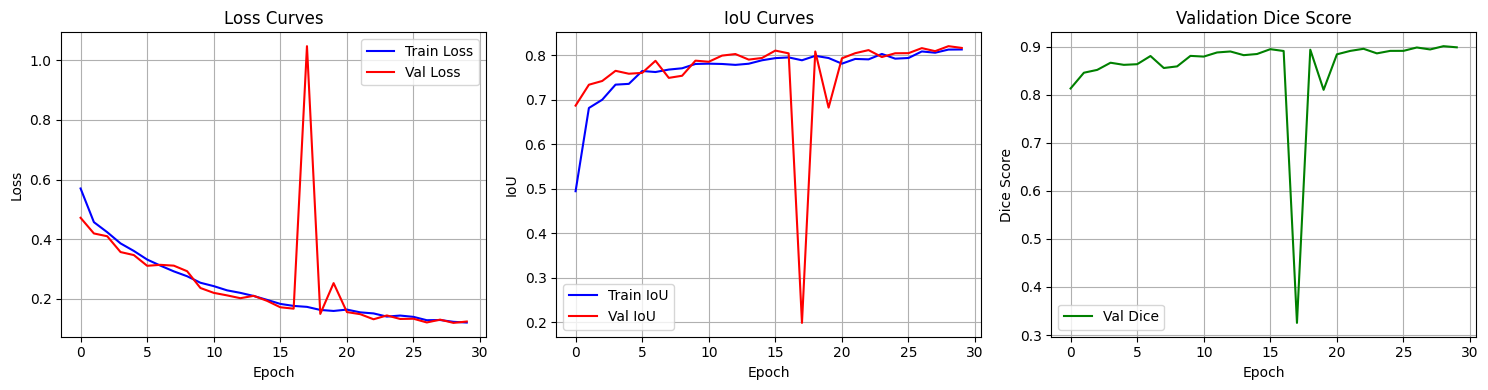

Saved: unet_training_curves.png
U-NET TRAINING SUMMARY
Best Validation Loss: 0.1188
Best Validation IoU: 0.8207
Best Validation Dice: 0.9008
Total Epochs Trained: 30

Cell 4 complete! (All sub-cells ran successfully)
Files saved:
   - unet_model.pth
   - unet_history.json
   - unet_training_curves.png


In [11]:
# Cell 4f: Save Model, History, and Plot Curves

import json
import matplotlib.pyplot as plt

# Save model weights
torch.save({
    'model_state_dict': unet.state_dict(),
    'history': history,
    'best_val_loss': best_val_loss,
    'model_name': 'U-Net'
}, '/kaggle/working/unet_model.pth')
print("✓ Saved: unet_model.pth")

# Save training history as JSON
history_json = {
    'train_loss': [float(x) for x in history['train_loss']],
    'val_loss': [float(x) for x in history['val_loss']],
    'train_iou': [float(x) for x in history['train_iou']],
    'val_iou': [float(x) for x in history['val_iou']],
    'val_dice': [float(x) for x in history['val_dice']],
    'lr': [float(x) for x in history['lr']]
}

with open('/kaggle/working/unet_history.json', 'w') as f:
    json.dump(history_json, f, indent=2)
print("Saved: unet_history.json")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True)

# IoU curve
axes[1].plot(history['train_iou'], label='Train IoU', color='blue')
axes[1].plot(history['val_iou'], label='Val IoU', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('IoU Curves')
axes[1].legend()
axes[1].grid(True)

# Dice curve
axes[2].plot(history['val_dice'], label='Val Dice', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Dice Score')
axes[2].set_title('Validation Dice Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/unet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: unet_training_curves.png")

print("U-NET TRAINING SUMMARY")

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation IoU: {max(history['val_iou']):.4f}")
print(f"Best Validation Dice: {max(history['val_dice']):.4f}")
print(f"Total Epochs Trained: {len(history['train_loss'])}")

print("\nCell 4 complete! (All sub-cells ran successfully)")
print("Files saved:")
print("   - unet_model.pth")
print("   - unet_history.json")
print("   - unet_training_curves.png")

VISUALIZING U-NET PREDICTIONS


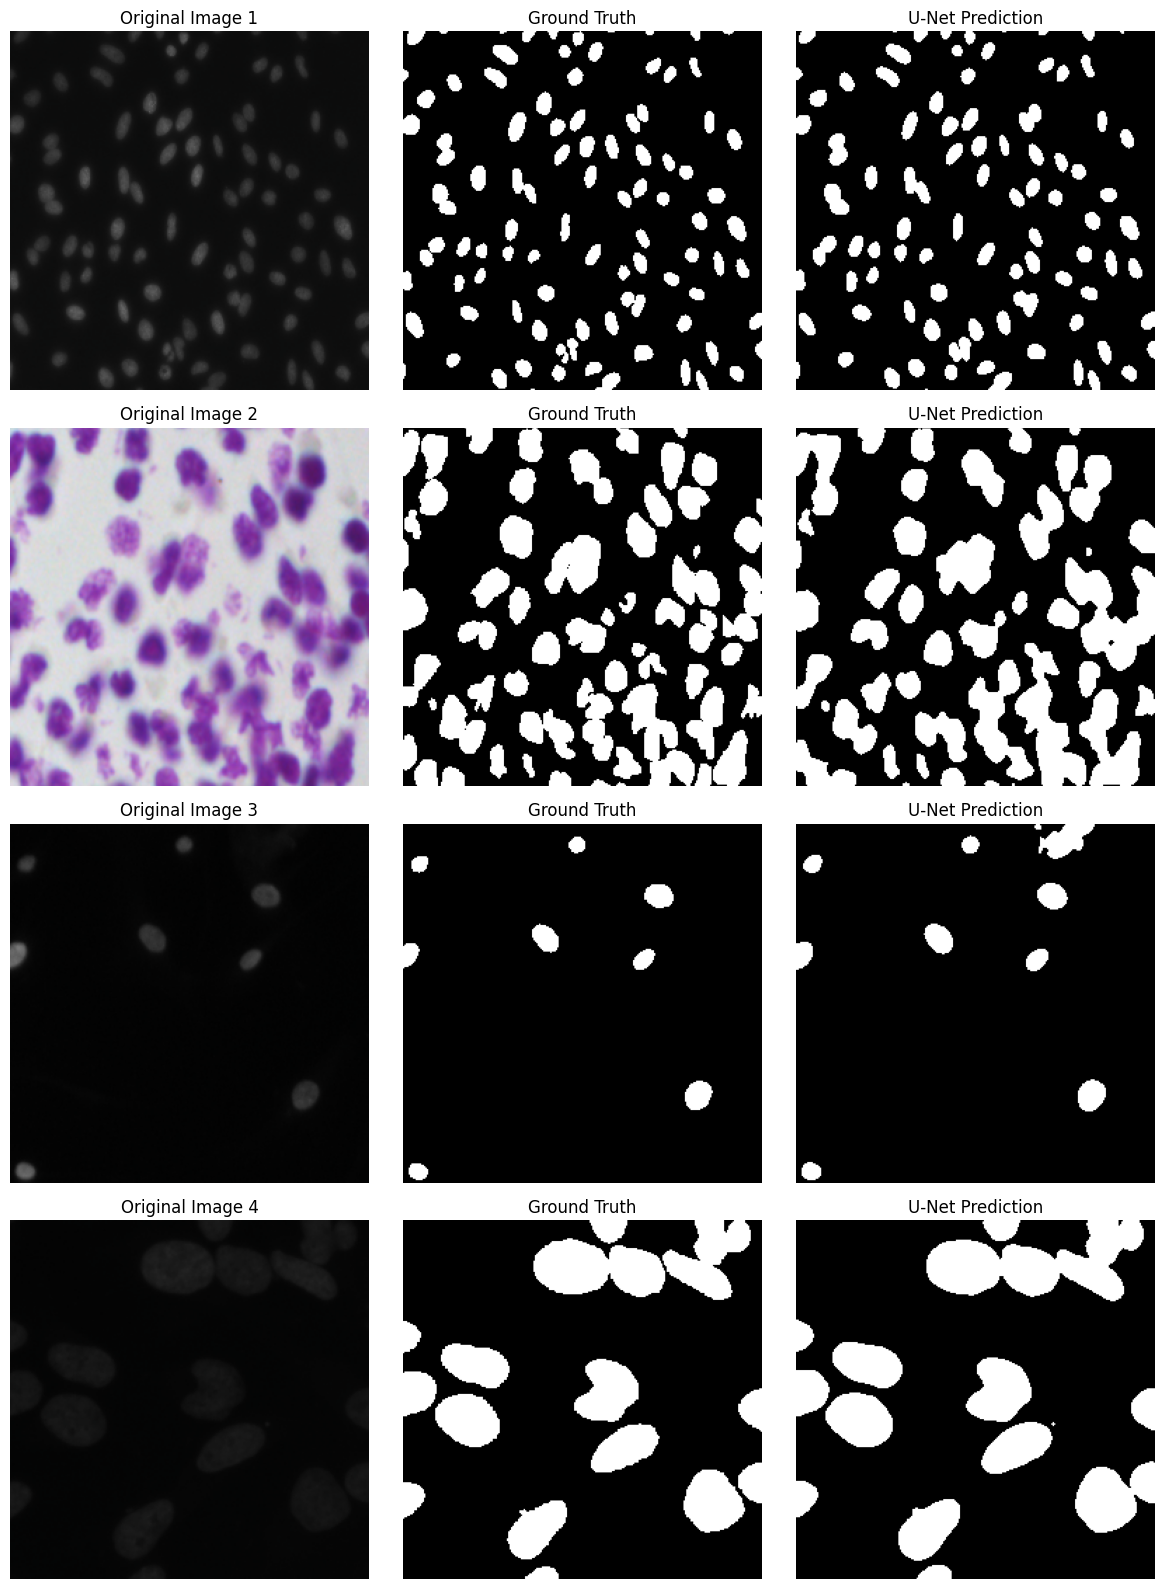

Saved: unet_predictions.png

U-Net training and visualization complete!


In [12]:
# Cell 4g: Visualize U-Net Predictions on Validation Set

print("="*40)
print("VISUALIZING U-NET PREDICTIONS")
print("="*40)

# Get a batch of validation images
unet.eval()
val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

# Get predictions
with torch.no_grad():
    val_outputs = unet(val_images)
    val_probs = torch.sigmoid(val_outputs)  # Convert logits to probabilities
    val_preds = (val_probs > 0.5).float()

# Move to CPU for visualization
val_images_cpu = val_images.cpu()
val_masks_cpu = val_masks.cpu()
val_preds_cpu = val_preds.cpu()

# Denormalize function (reverse the normalization)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def denormalize(image):
    image = image.permute(1, 2, 0).numpy()
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# Show 4 examples
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for idx in range(4):
    # Original image
    axes[idx, 0].imshow(denormalize(val_images_cpu[idx]))
    axes[idx, 0].set_title(f'Original Image {idx+1}')
    axes[idx, 0].axis('off')
    
    # Ground truth mask
    axes[idx, 1].imshow(val_masks_cpu[idx, 0].numpy(), cmap='gray')
    axes[idx, 1].set_title(f'Ground Truth')
    axes[idx, 1].axis('off')
    
    # Prediction
    axes[idx, 2].imshow(val_preds_cpu[idx, 0].numpy(), cmap='gray')
    axes[idx, 2].set_title(f'U-Net Prediction')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: unet_predictions.png")
print("\nU-Net training and visualization complete!")

# Attention U-Net

In [13]:
# Cell 5a: Attention U-Net Model (Modern approach with attention gates)

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)

class AttentionGate(nn.Module):
    """Attention Gate for focusing on relevant features"""
    def __init__(self, F_g, F_l, F_int):
        """
        F_g: Number of channels in gating signal (decoder)
        F_l: Number of channels in skip connection (encoder)
        F_int: Number of intermediate channels
        """
        super(AttentionGate, self).__init__()
        
        # Gating signal transformation
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Skip connection transformation
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        # Attention weights
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        # g: gating signal from decoder
        # x: skip connection from encoder
        
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        # Combine and apply ReLU
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)  # Attention coefficients
        
        # Apply attention to skip connection
        return x * psi

class UpWithAttention(nn.Module):
    """Upscaling then DoubleConv with Attention Gate"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(UpWithAttention, self).__init__()
        
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        
        # Attention gate
        self.attention = AttentionGate(F_g=in_channels // 2, F_l=in_channels // 2, F_int=in_channels // 4)
        
        # Double convolution after concatenation
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        # x1: decoder output (to be upsampled)
        # x2: skip connection from encoder
        
        x1 = self.up(x1)
        
        # Handle size mismatch
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Apply attention to skip connection
        x2_attended = self.attention(x1, x2)
        
        # Concatenate
        x = torch.cat([x2_attended, x1], dim=1)
        
        # Double convolution
        return self.conv(x)

class OutConv(nn.Module):
    """Final 1x1 convolution to get 1 channel output (logits)"""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)

class AttentionUNet(nn.Module):
    """Attention U-Net for binary segmentation"""
    def __init__(self, n_channels=3, n_classes=1, bilinear=True):
        super(AttentionUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        # Encoder (same as U-Net)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Decoder with Attention Gates
        self.up1 = UpWithAttention(1024, 512 // factor, bilinear)
        self.up2 = UpWithAttention(512, 256 // factor, bilinear)
        self.up3 = UpWithAttention(256, 128 // factor, bilinear)
        self.up4 = UpWithAttention(128, 64, bilinear)
        
        # Output
        self.outc = OutConv(64, n_classes)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)      # 64 channels
        x2 = self.down1(x1)   # 128
        x3 = self.down2(x2)   # 256
        x4 = self.down3(x3)   # 512
        x5 = self.down4(x4)   # 512/1024
        
        # Decoder with attention gates
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Output logits (no sigmoid)
        logits = self.outc(x)
        return logits

# Initialize model
attention_unet = AttentionUNet(n_channels=3, n_classes=1).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Attention U-Net created successfully!")
print(f"  Total parameters: {count_parameters(attention_unet):,}")
print(f"  U-Net had: 13,395,329 parameters")
print(f"  Difference: +{count_parameters(attention_unet) - 13395329:,} parameters (attention gates)")
print(f"  Input: [batch, 3, 256, 256]")
print(f"  Output: [batch, 1, 256, 256]")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(1, 3, 256, 256).to(device)
    test_output = attention_unet(test_input)
    print(f"\nForward pass test passed!")
    print(f"  Output shape: {test_output.shape}")



✓ Attention U-Net created successfully!
  Total parameters: 13,746,861
  U-Net had: 13,395,329 parameters
  Difference: +351,532 parameters (attention gates)
  Input: [batch, 3, 256, 256]
  Output: [batch, 1, 256, 256]

Forward pass test passed!
  Output shape: torch.Size([1, 1, 256, 256])


## Train Attention U-Net

In [14]:
from torch.cuda.amp import GradScaler
import torch.optim as optim
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

# Initialize model (fresh start)
attention_unet = AttentionUNet(n_channels=3, n_classes=1).to(device)

# Loss function (same as U-Net)
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

# Optimizer
optimizer = optim.Adam(attention_unet.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Mixed precision scaler
scaler = GradScaler() if device.type == 'cuda' else None

# Training parameters
EPOCHS = 30
PATIENCE = 10

print(f"✓ Model: Attention U-Net")
print(f"✓ Loss: BCEWithLogitsLoss + Dice Loss")
print(f"✓ Optimizer: Adam (lr=1e-4)")
print(f"✓ Epochs: {EPOCHS}")
print(f"✓ Patience: {PATIENCE}")

# Training loop
print("\n" + "="*40)
print("STARTING ATTENTION U-NET TRAINING")
print("="*40)

# Store metrics
history_attention = {
    'train_loss': [],
    'val_loss': [],
    'train_iou': [],
    'val_iou': [],
    'val_dice': [],
    'lr': []
}

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)
    
    # Train
    train_loss, train_iou = train_epoch(attention_unet, train_loader, optimizer, criterion, device, scaler)
    
    # Validate
    val_loss, val_iou, val_dice = validate_epoch(attention_unet, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history_attention['train_loss'].append(train_loss)
    history_attention['val_loss'].append(val_loss)
    history_attention['train_iou'].append(train_iou)
    history_attention['val_iou'].append(val_iou)
    history_attention['val_dice'].append(val_dice)
    history_attention['lr'].append(current_lr)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}, Val Dice: {val_dice:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")
    
    # Early stopping & save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = attention_unet.state_dict().copy()
        print(f"✓ New best model! (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")
        
        if patience_counter >= PATIENCE:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
if best_model_state:
    attention_unet.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model with val_loss: {best_val_loss:.4f}")

print("\n✓ ATTENTION U-NET TRAINING COMPLETE")

# Save model
torch.save({
    'model_state_dict': attention_unet.state_dict(),
    'history': history_attention,
    'best_val_loss': best_val_loss,
    'model_name': 'Attention U-Net'
}, '/kaggle/working/attention_unet_model.pth')
print("✓ Saved: attention_unet_model.pth")

# Save history
history_attention_json = {
    'train_loss': [float(x) for x in history_attention['train_loss']],
    'val_loss': [float(x) for x in history_attention['val_loss']],
    'train_iou': [float(x) for x in history_attention['train_iou']],
    'val_iou': [float(x) for x in history_attention['val_iou']],
    'val_dice': [float(x) for x in history_attention['val_dice']],
    'lr': [float(x) for x in history_attention['lr']]
}

with open('/kaggle/working/attention_unet_history.json', 'w') as f:
    json.dump(history_attention_json, f, indent=2)
print("Saved: attention_unet_history.json")

/tmp/ipykernel_56/544554245.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type == 'cuda' else None


✓ Model: Attention U-Net
✓ Loss: BCEWithLogitsLoss + Dice Loss
✓ Optimizer: Adam (lr=1e-4)
✓ Epochs: 30
✓ Patience: 10

STARTING ATTENTION U-NET TRAINING

Epoch 1/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  4.12it/s]


Train Loss: 0.4989, Train IoU: 0.5446
Val Loss: 0.4399, Val IoU: 0.5731, Val Dice: 0.7189
Learning Rate: 0.000100
✓ New best model! (val_loss: 0.4399)

Epoch 2/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  3.84it/s]


...

Train Loss: 0.1243, Train IoU: 0.8000
Val Loss: 0.1224, Val IoU: 0.8022, Val Dice: 0.8896
Learning Rate: 0.000100
No improvement for 3 epochs

Epoch 29/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  3.95it/s]


Train Loss: 0.1241, Train IoU: 0.7982
Val Loss: 0.1174, Val IoU: 0.8099, Val Dice: 0.8942
Learning Rate: 0.000100
No improvement for 4 epochs

Epoch 30/30
------------------------------


Validation: 100%|██████████| 17/17 [00:04<00:00,  3.88it/s]


Train Loss: 0.1223, Train IoU: 0.7992
Val Loss: 0.1097, Val IoU: 0.8149, Val Dice: 0.8972
Learning Rate: 0.000100
✓ New best model! (val_loss: 0.1097)

✓ Loaded best model with val_loss: 0.1097

✓ ATTENTION U-NET TRAINING COMPLETE
✓ Saved: attention_unet_model.pth
Saved: attention_unet_history.json


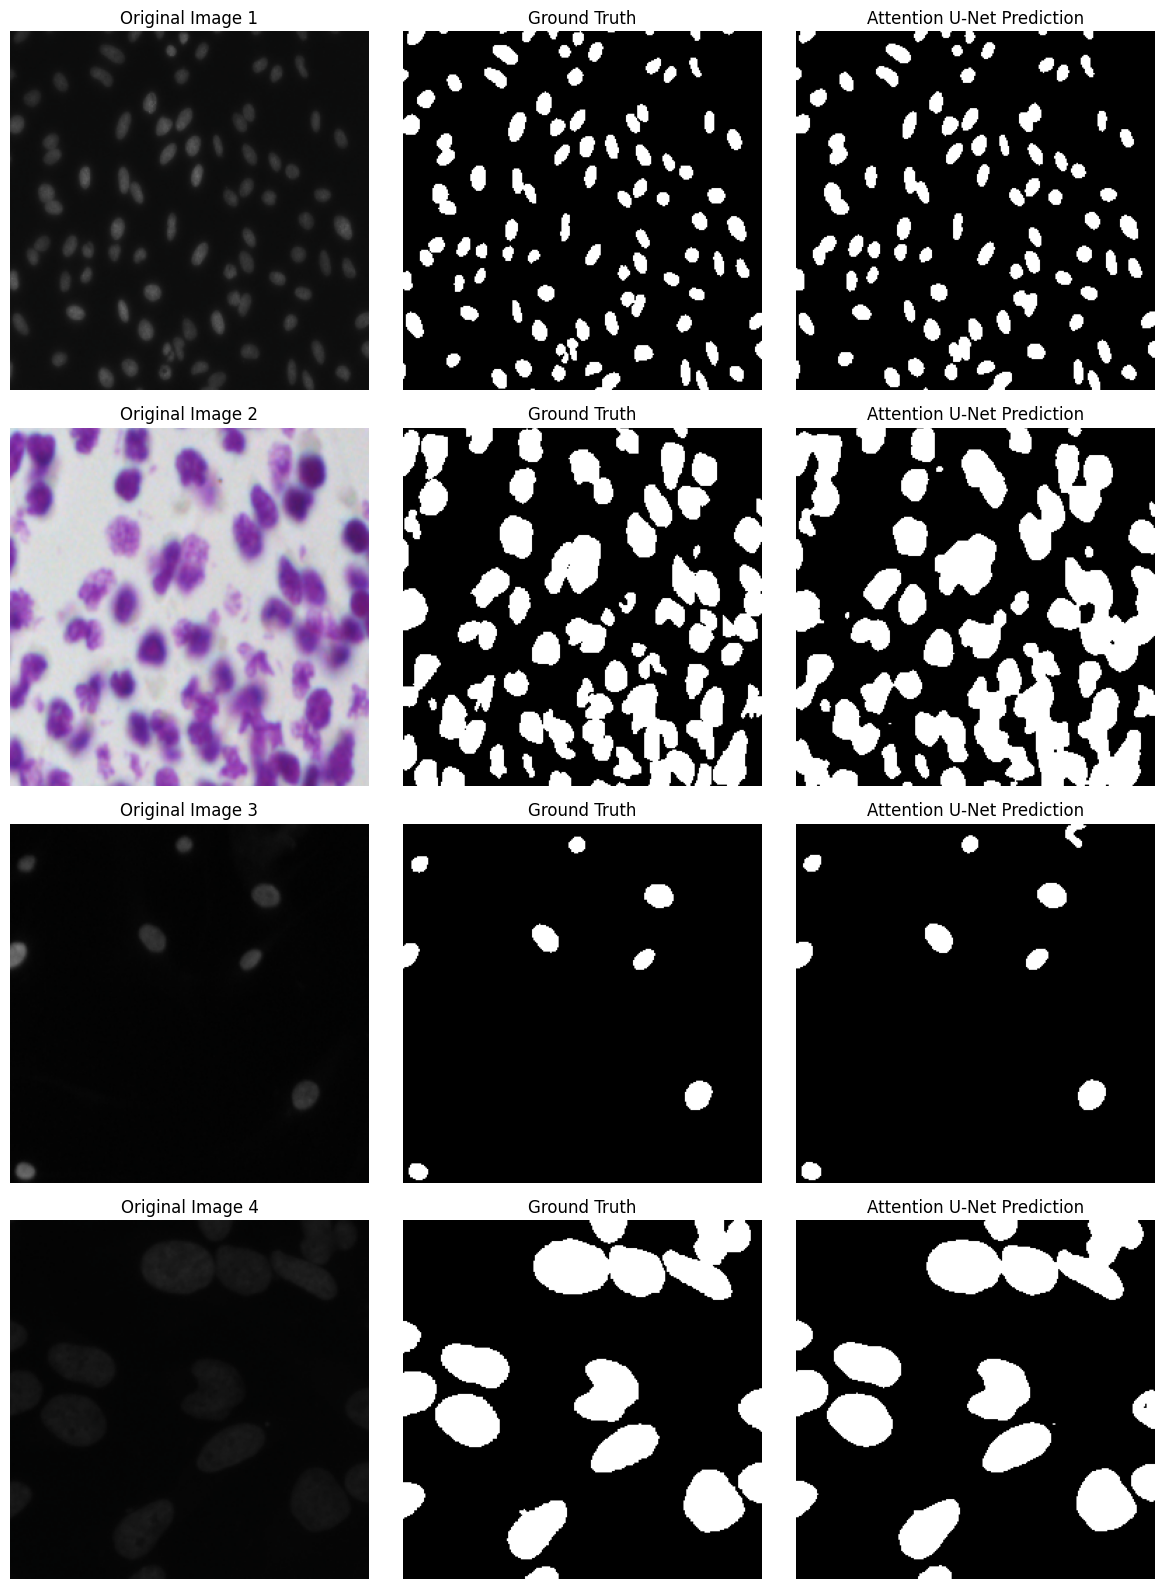

✓ Saved: attention_unet_predictions.png


In [15]:
# Cell 5c: Visualize Attention U-Net Predictions

# Get a batch of validation images
attention_unet.eval()
val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

# Get predictions
with torch.no_grad():
    val_outputs = attention_unet(val_images)
    val_probs = torch.sigmoid(val_outputs)
    val_preds = (val_probs > 0.5).float()

# Move to CPU
val_images_cpu = val_images.cpu()
val_masks_cpu = val_masks.cpu()
val_preds_cpu = val_preds.cpu()

# Denormalize function
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def denormalize(image):
    image = image.permute(1, 2, 0).numpy()
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# Show 4 examples
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for idx in range(4):
    axes[idx, 0].imshow(denormalize(val_images_cpu[idx]))
    axes[idx, 0].set_title(f'Original Image {idx+1}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(val_masks_cpu[idx, 0].numpy(), cmap='gray')
    axes[idx, 1].set_title(f'Ground Truth')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(val_preds_cpu[idx, 0].numpy(), cmap='gray')
    axes[idx, 2].set_title(f'Attention U-Net Prediction')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/attention_unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: attention_unet_predictions.png")

In [ ]:
# Cell 6: Compare Both Models

import json
import matplotlib.pyplot as plt
import numpy as np

# Load histories (if from saved files, otherwise use variables)
if 'history' in locals():
    unet_history = history
else:
    with open('/kaggle/working/unet_history.json', 'r') as f:
        unet_history = json.load(f)

if 'history_attention' in locals():
    att_history = history_attention
else:
    with open('/kaggle/working/attention_unet_history.json', 'r') as f:
        att_history = json.load(f)

# Get best metrics
unet_best_iou = max(unet_history['val_iou'])
unet_best_dice = max(unet_history['val_dice'])
unet_best_loss = min(unet_history['val_loss'])

att_best_iou = max(att_history['val_iou'])
att_best_dice = max(att_history['val_dice'])
att_best_loss = min(att_history['val_loss'])

# Print comparison table
print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'U-Net':<15} {'Attention U-Net':<15} {'Improvement':<10}")
print("-"*60)
print(f"{'Best Val Loss':<20} {unet_best_loss:<15.4f} {att_best_loss:<15.4f} {(unet_best_loss - att_best_loss):+.4f}")
print(f"{'Best Val IoU':<20} {unet_best_iou:<15.4f} {att_best_iou:<15.4f} {(att_best_iou - unet_best_iou):+.4f}")
print(f"{'Best Val Dice':<20} {unet_best_dice:<15.4f} {att_best_dice:<15.4f} {(att_best_dice - unet_best_dice):+.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss comparison
axes[0].plot(unet_history['val_loss'], label='U-Net', color='blue', linewidth=2)
axes[0].plot(att_history['val_loss'], label='Attention U-Net', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].legend()
axes[0].grid(True)

# IoU comparison
axes[1].plot(unet_history['val_iou'], label='U-Net', color='blue', linewidth=2)
axes[1].plot(att_history['val_iou'], label='Attention U-Net', color='red', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU Comparison')
axes[1].legend()
axes[1].grid(True)

# Dice comparison
axes[2].plot(unet_history['val_dice'], label='U-Net', color='blue', linewidth=2)
axes[2].plot(att_history['val_dice'], label='Attention U-Net', color='red', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Dice Score')
axes[2].set_title('Validation Dice Comparison')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Saved: model_comparison.png")

# Final summary

print("FINAL SUMMARY")

print(f"U-Net:")
print(f"   - Best Validation IoU: {unet_best_iou:.4f}")
print(f"   - Best Validation Dice: {unet_best_dice:.4f}")
print(f"   - Parameters: 13,395,329")

print(f"\n📊 Attention U-Net:")
print(f"   - Best Validation IoU: {att_best_iou:.4f}")
print(f"   - Best Validation Dice: {att_best_dice:.4f}")
print(f"   - Parameters: {count_parameters(attention_unet):,}")

print(f"\n Improvement with Attention:")
print(f"   - IoU: +{(att_best_iou - unet_best_iou)*100:.2f}%")
print(f"   - Dice: +{(att_best_dice - unet_best_dice)*100:.2f}%")

print("\nCell 6 complete!")
print("\nAll files saved for your report:")
print("   - unet_model.pth")
print("   - unet_history.json")
print("   - unet_training_curves.png")
print("   - unet_predictions.png")
print("   - attention_unet_model.pth")
print("   - attention_unet_history.json")
print("   - attention_unet_predictions.png")
print("   - model_comparison.png")


PERFORMANCE COMPARISON
Metric               U-Net           Attention U-Net Improvement
------------------------------------------------------------
Best Val Loss        0.1188          0.1097          +0.0091
Best Val IoU         0.8207          0.8152          -0.0055
Best Val Dice        0.9008          0.8974          -0.0033


DETAILED ANALYSIS

 Performance Difference:
   IoU:  0.8207 → 0.8152 (-0.55%)
   Dice: 0.9008 → 0.8974 (-0.33%)

💡 Conclusion:
   → Both models perform similarly on this dataset
   → Attention U-Net does not provide significant advantage
   → U-Net is sufficient for clean microscopy data


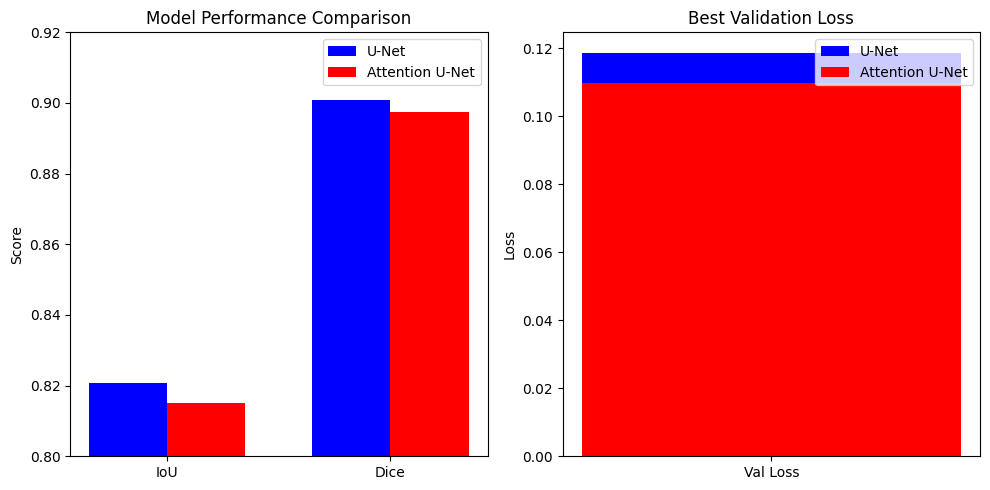


Saved: final_comparison.png


In [17]:
# Cell 6b: Detailed Comparison (Add this)

print("="*50)
print("DETAILED ANALYSIS")
print("="*50)

# Calculate improvements
iou_improvement = (att_best_iou - unet_best_iou) * 100
dice_improvement = (att_best_dice - unet_best_dice) * 100

print(f"\n Performance Difference:")
print(f"   IoU:  {unet_best_iou:.4f} → {att_best_iou:.4f} ({iou_improvement:+.2f}%)")
print(f"   Dice: {unet_best_dice:.4f} → {att_best_dice:.4f} ({dice_improvement:+.2f}%)")

print(f"\n💡 Conclusion:")
if abs(iou_improvement) < 1:
    print("   → Both models perform similarly on this dataset")
    print("   → Attention U-Net does not provide significant advantage")
    print("   → U-Net is sufficient for clean microscopy data")
else:
    print("   → Attention U-Net shows clear improvement")
    print("   → Recommend using Attention U-Net for this task")

# Bar chart comparison
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

metrics = ['IoU', 'Dice']
unet_scores = [unet_best_iou, unet_best_dice]
att_scores = [att_best_iou, att_best_dice]

x = np.arange(len(metrics))
width = 0.35

ax[0].bar(x - width/2, unet_scores, width, label='U-Net', color='blue')
ax[0].bar(x + width/2, att_scores, width, label='Attention U-Net', color='red')
ax[0].set_ylabel('Score')
ax[0].set_title('Model Performance Comparison')
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrics)
ax[0].legend()
ax[0].set_ylim(0.8, 0.92)

# Loss comparison
ax[1].bar(['Val Loss'], [unet_best_loss], width, label='U-Net', color='blue')
ax[1].bar(['Val Loss'], [att_best_loss], width, label='Attention U-Net', color='red')
ax[1].set_ylabel('Loss')
ax[1].set_title('Best Validation Loss')
ax[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: final_comparison.png")